# IMPORTS

In [3]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
import seaborn as sns
from pathlib import Path
from datetime import datetime
from windrose import WindroseAxes

# diive 
import importlib.metadata
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")
from diive.core.dfun.stats import sstats  # Time series stats
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.timeseries import TimeSeries  # For simple (interactive) time series plotting
from diive.core.plotting.heatmap_datetime import HeatmapDateTime, HeatmapYearMonth

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)

# Matplotlib defaults
plt.rcParams["figure.autolayout"] = True
plt.rcParams["figure.figsize"] = (10, 4)

diive version: v0.89.0


# LOAD DATA

In [4]:
FILEPATH = r"..\\60_USTAR_FILTERING\\62.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet"
data_original = load_parquet(filepath=FILEPATH)
maindf = data_original.copy()

maindf

Loaded .parquet file ..\\60_USTAR_FILTERING\\62.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet (1.531 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,BADM_HEIGHTC,BADM_INSTPAIR_EASTWARD_SEP_GA_CH4,BADM_INSTPAIR_EASTWARD_SEP_GA_CO2,BADM_INSTPAIR_EASTWARD_SEP_GA_H2O,BADM_INSTPAIR_EASTWARD_SEP_GA_N2O,BADM_INSTPAIR_HEIGHT_SEP_GA_CH4,BADM_INSTPAIR_HEIGHT_SEP_GA_CO2,BADM_INSTPAIR_HEIGHT_SEP_GA_H2O,BADM_INSTPAIR_HEIGHT_SEP_GA_N2O,...,FLAG_L3.3_CUT_50_FN2O_L3.2_QCF0_USTAR_TEST,FN2O_L3.3_CUT_84_QCF0,FLAG_L3.3_CUT_84_FN2O_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_16_QCF,FLAG_L3.3_CUT_16_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_50_QCF,FLAG_L3.3_CUT_50_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_84_QCF,FLAG_L3.3_CUT_84_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_16_QCF0,FLAG_L3.3_CUT_16_FCH4_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_50_QCF0,FLAG_L3.3_CUT_50_FCH4_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_84_QCF0,FLAG_L3.3_CUT_84_FCH4_L3.2_QCF0_USTAR_TEST
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-07 15:45:00,1009.65,1.18057,0.024459,1191.96,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-11-07 16:15:00,1009.74,1.18107,0.024448,1192.57,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,0.0,0.324973,0.0,-4.360399,0.0,-4.360399,0.0,-4.360399,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-11-07 16:45:00,1009.93,1.18176,0.024430,1193.50,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,0.0,0.053551,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-11-07 17:15:00,1009.97,1.18428,0.024377,1196.09,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,0.0,0.339963,0.0,2.488800,0.0,2.488800,0.0,2.488800,0.0,2.488800,0.0,2.488800,0.0,2.488800,0.0
2023-11-07 17:45:00,1010.06,1.18448,0.024372,1196.40,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,0.0,-0.983566,0.0,-9.177059,0.0,-9.177059,0.0,-9.177059,0.0,-9.177059,0.0,-9.177059,0.0,-9.177059,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 22:45:00,1014.01,1.14117,0.025232,1157.16,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,-0.069384,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0
2025-06-04 23:15:00,1014.04,1.14156,0.025222,1157.59,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,-0.288296,0.0,-1.904577,0.0,-1.904577,0.0,-1.904577,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2025-06-04 23:45:00,1013.47,1.14369,0.025185,1159.10,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,0.220511,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0


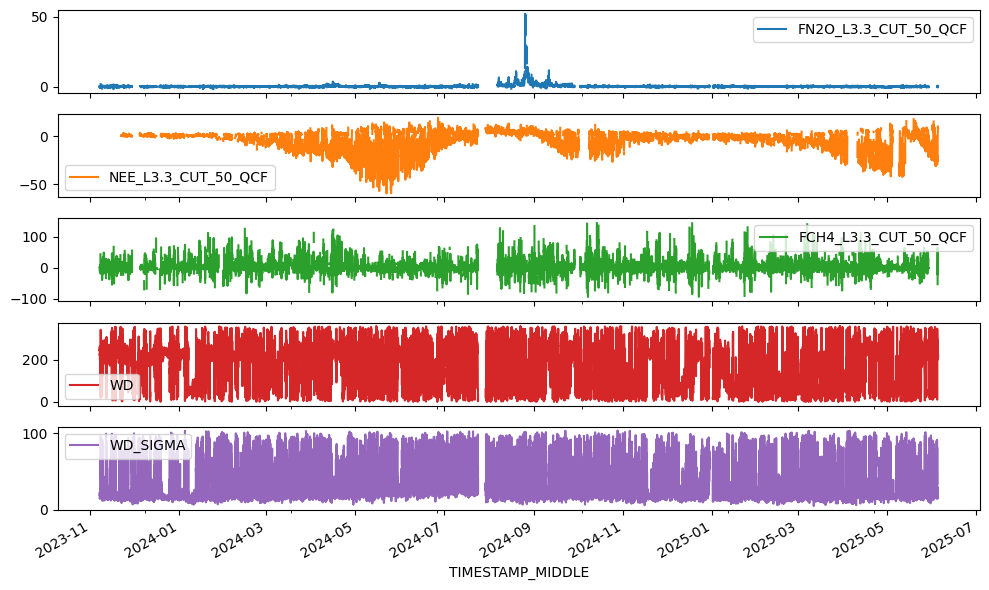

In [5]:
# Select fluxes
FLUXES = ['FN2O_L3.3_CUT_50_QCF', 'NEE_L3.3_CUT_50_QCF', 'FCH4_L3.3_CUT_50_QCF']
WIND = ['WD', 'WD_SIGMA']
# Plot time series 
ax = maindf[FLUXES + WIND].plot(subplots=True, figsize=(10, 6), x_compat=True)
plt.show()

# WIND ROSES

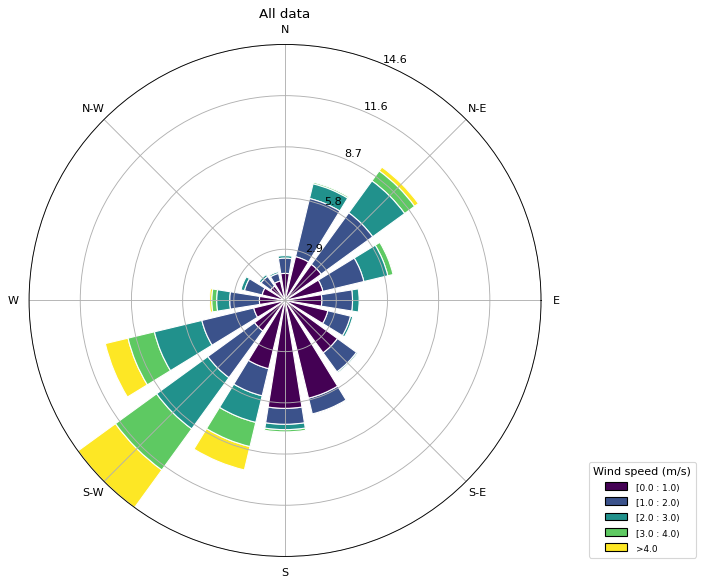

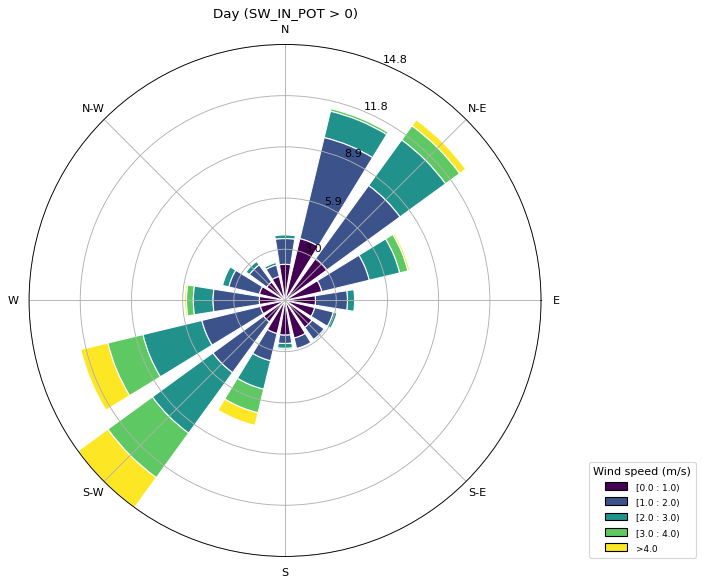

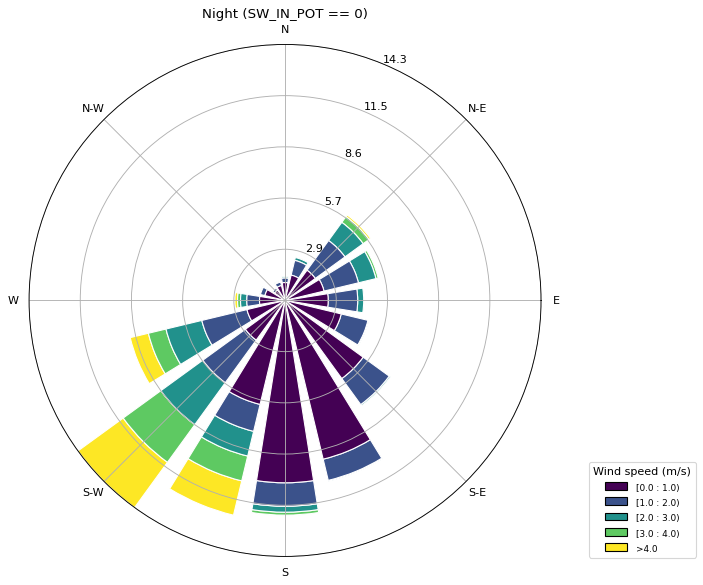

In [6]:
# Classify day/night
df = maindf.copy()
df["period"] = df["SW_IN_POT"].apply(lambda x: "Day" if x > 0 else "Night")

# Function to plot windrose
def plot_windrose(data, title):
    ax = WindroseAxes.from_ax()
    ax.bar(
        data["WD"], data["WS"],
        normed=True, opening=0.8, edgecolor="white",
        bins=[0,1,2,3,4],
        cmap=plt.cm.viridis
    )
    ax.set_title(title, fontsize=12)
    ax.set_legend(title="Wind speed (m/s)", loc="lower right", bbox_to_anchor=(1.3, 0))
    return ax

# --- Full data windrose ---
plot_windrose(df, "All data")

# --- Daytime windrose ---
plot_windrose(df[df["period"]=="Day"], "Day (SW_IN_POT > 0)")

# --- Nighttime windrose ---
plot_windrose(df[df["period"]=="Night"], "Night (SW_IN_POT == 0)")

plt.show()


# SPLIT INTO PARCELS

We assume the division line lies between 87° and 267°. A symmetric buffer is used to avoid ambiguous assignment.

In [7]:
wd  = maindf['WD']
sig = maindf['WD_SIGMA']
buffer = 3.0  # degrees; set to 0 if you don't want a center buffer

# interval edges (handle wrap)
factor = 1  # how many sigma to use for the interval
lo = (wd - (sig * factor)) % 360
hi = (wd + (sig * factor)) % 360
wraps = lo > hi

# --- FULL windows (for interval containment, no buffer) ---
# A_full = [0,87) ∪ (267,360]; B_full = (87,26)
lower_angle = 87
higher_angle = 287
A_full = ((~wraps) & (lo >= 0)   & (hi <= lower_angle)) | \
         ((~wraps) & (lo >= higher_angle) & (hi <= 360)) | \
         (wraps    & (hi <= lower_angle)  & (lo >= higher_angle))
B_full = (~wraps) & (lo >= lower_angle) & (hi <= higher_angle)

# --- SHRUNK windows (for center classification with buffer) ---
center_A_shrunk = ((wd >= 0 + buffer)   & (wd <  lower_angle - buffer)) | \
                  ((wd >  higher_angle + buffer) & (wd <= 360 - buffer))
center_B_shrunk =  (wd >  lower_angle + buffer)  & (wd <  higher_angle - buffer)
center_buffer   = ~(center_A_shrunk | center_B_shrunk) & wd.notna()

# --- certainty logic ---
A_certain   = center_A_shrunk & A_full
A_uncertain = center_A_shrunk & ~A_full

B_certain   = center_B_shrunk & B_full
B_uncertain = center_B_shrunk & ~B_full

# --- labels (init with NaN so missing WD stays NaN) ---
maindf['parcel'] = np.nan
maindf['parcel_certainty'] = np.nan

maindf.loc[center_buffer,     'parcel'] = 'buffer'
maindf.loc[center_A_shrunk,   'parcel'] = 'A'
maindf.loc[center_B_shrunk,   'parcel'] = 'B'

maindf.loc[A_certain | B_certain,   'parcel_certainty'] = 'certain'
maindf.loc[A_uncertain | B_uncertain, 'parcel_certainty'] = 'uncertain'


# Data loss to buffer and uncertainty assessment
for flux in FLUXES:
    total_count = maindf[flux].notna().sum()
    buffer_count = maindf.loc[maindf['parcel'] == 'buffer', flux].notna().sum()
    uncertain_count = maindf.loc[maindf['parcel_certainty'] == 'uncertain', flux].notna().sum()
    perc_loss_buffer   = buffer_count   / total_count * 100 if total_count else np.nan
    perc_loss_uncertain = uncertain_count / total_count * 100 if total_count else np.nan
    print(f"{flux}: {perc_loss_buffer:.2f}% lost to buffer ({buffer}°), "
          f"{perc_loss_uncertain:.2f}% uncertain")

maindf

FN2O_L3.3_CUT_50_QCF: 2.44% lost to buffer (3.0°), 20.71% uncertain
NEE_L3.3_CUT_50_QCF: 2.54% lost to buffer (3.0°), 18.87% uncertain
FCH4_L3.3_CUT_50_QCF: 2.29% lost to buffer (3.0°), 20.91% uncertain


,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,BADM_HEIGHTC,BADM_INSTPAIR_EASTWARD_SEP_GA_CH4,BADM_INSTPAIR_EASTWARD_SEP_GA_CO2,BADM_INSTPAIR_EASTWARD_SEP_GA_H2O,BADM_INSTPAIR_EASTWARD_SEP_GA_N2O,BADM_INSTPAIR_HEIGHT_SEP_GA_CH4,BADM_INSTPAIR_HEIGHT_SEP_GA_CO2,BADM_INSTPAIR_HEIGHT_SEP_GA_H2O,BADM_INSTPAIR_HEIGHT_SEP_GA_N2O,...,FLAG_L3.3_CUT_84_FN2O_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_16_QCF,FLAG_L3.3_CUT_16_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_50_QCF,FLAG_L3.3_CUT_50_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_84_QCF,FLAG_L3.3_CUT_84_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_16_QCF0,FLAG_L3.3_CUT_16_FCH4_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_50_QCF0,FLAG_L3.3_CUT_50_FCH4_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_84_QCF0,FLAG_L3.3_CUT_84_FCH4_L3.2_QCF0_USTAR_TEST,parcel,parcel_certainty
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-07 15:45:00,1009.65,1.18057,0.024459,1191.96,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,B,certain
2023-11-07 16:15:00,1009.74,1.18107,0.024448,1192.57,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,0.0,-4.360399,0.0,-4.360399,0.0,-4.360399,0.0,NaN,0.0,NaN,0.0,NaN,0.0,B,certain
2023-11-07 16:45:00,1009.93,1.18176,0.024430,1193.50,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,B,certain
2023-11-07 17:15:00,1009.97,1.18428,0.024377,1196.09,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,0.0,2.488800,0.0,2.488800,0.0,2.488800,0.0,2.488800,0.0,2.488800,0.0,2.488800,0.0,B,certain
2023-11-07 17:45:00,1010.06,1.18448,0.024372,1196.40,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,0.0,-9.177059,0.0,-9.177059,0.0,-9.177059,0.0,-9.177059,0.0,-9.177059,0.0,-9.177059,0.0,B,certain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 22:45:00,1014.01,1.14117,0.025232,1157.16,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0,B,certain
2025-06-04 23:15:00,1014.04,1.14156,0.025222,1157.59,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,-1.904577,0.0,-1.904577,0.0,-1.904577,0.0,NaN,0.0,NaN,0.0,NaN,0.0,B,certain
2025-06-04 23:45:00,1013.47,1.14369,0.025185,1159.10,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,B,certain


# CHECK DAY-NIGHT DISTRIBUTION

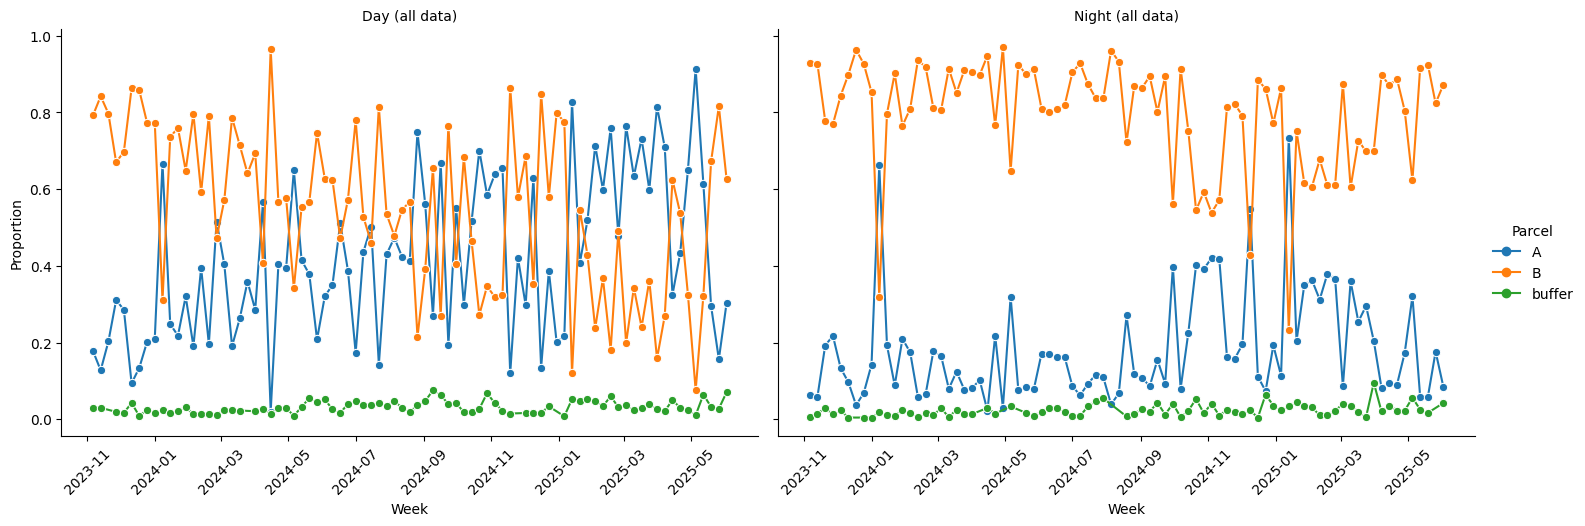

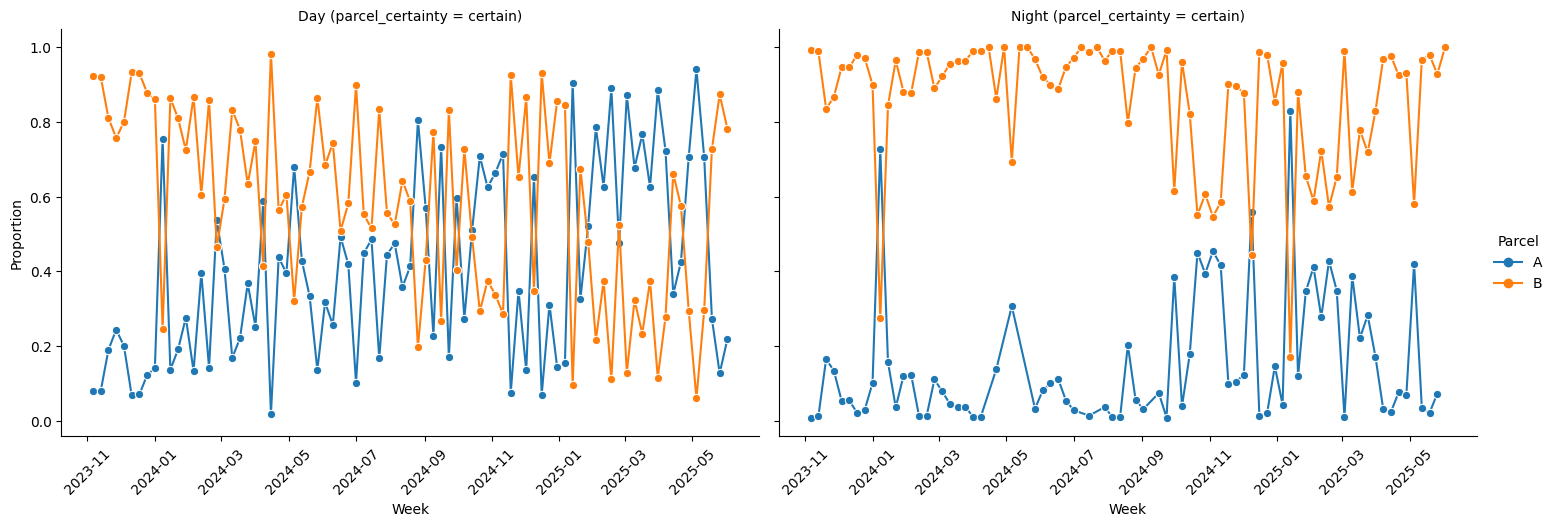

In [8]:
def plot_weekly_distribution(df, title_suffix=""):
    # Make sure timestamp is datetime
    df["TIMESTAMP_MIDDLE"] = pd.to_datetime(df["TIMESTAMP_MIDDLE"])

    # Extract year-week
    df["week_start"] = df["TIMESTAMP_MIDDLE"].dt.to_period("W").apply(lambda r: r.start_time)

    # Classify day vs night
    df["period"] = df["SW_IN_POT"].apply(lambda x: "Day" if x > 0 else "Night")

    # Count
    counts = (
        df.groupby(["week_start","period","parcel"])
          .size().reset_index(name="n")
    )

    # Normalize to proportions
    counts["prop"] = counts.groupby(["week_start","period"])["n"].transform(lambda x: x / x.sum())
    counts = counts.sort_values("week_start")

    # Plot
    g = sns.relplot(
        data=counts,
        x="week_start", y="prop", hue="parcel",
        col="period", kind="line",
        height=5, aspect=1.5,
        marker="o"
    )

    g.set_axis_labels("Week", "Proportion")
    g.set_titles("{col_name} " + title_suffix)
    g._legend.set_title("Parcel")
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=45)

    plt.show()


# Full dataset
plot_weekly_distribution(maindf.reset_index().copy(), title_suffix="(all data)")

# Subset: parcel_certainty == 'certain'
df_certain = maindf[maindf['parcel_certainty']=='certain'].reset_index().copy()
plot_weekly_distribution(df_certain, title_suffix="(parcel_certainty = certain)")


# PLOTS

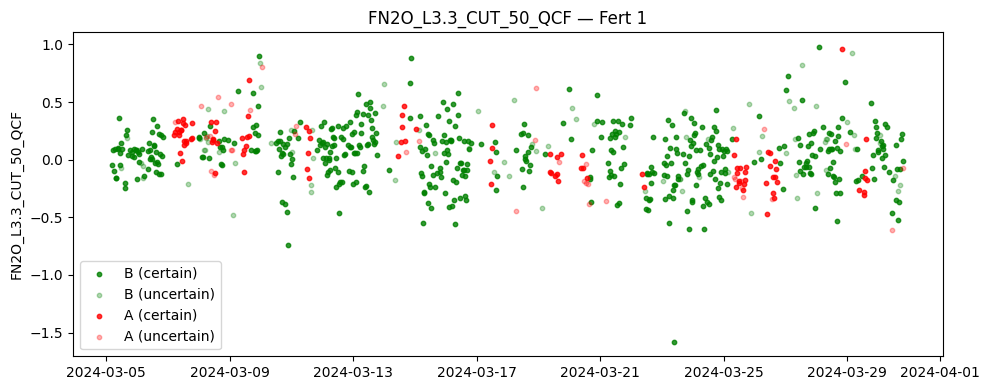

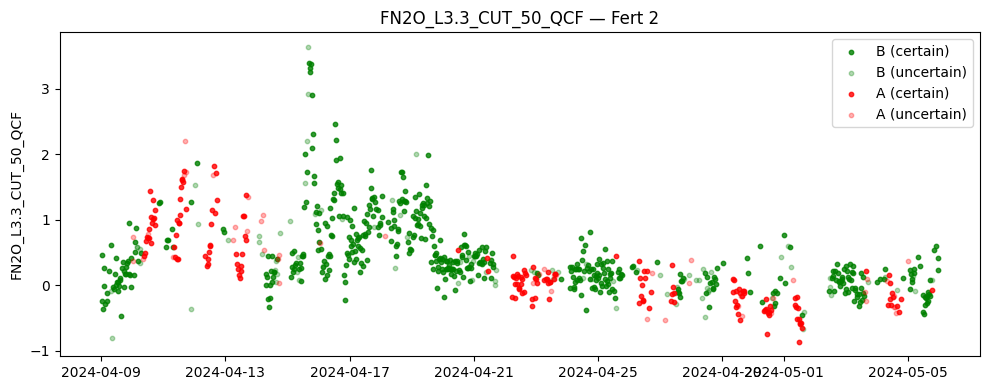

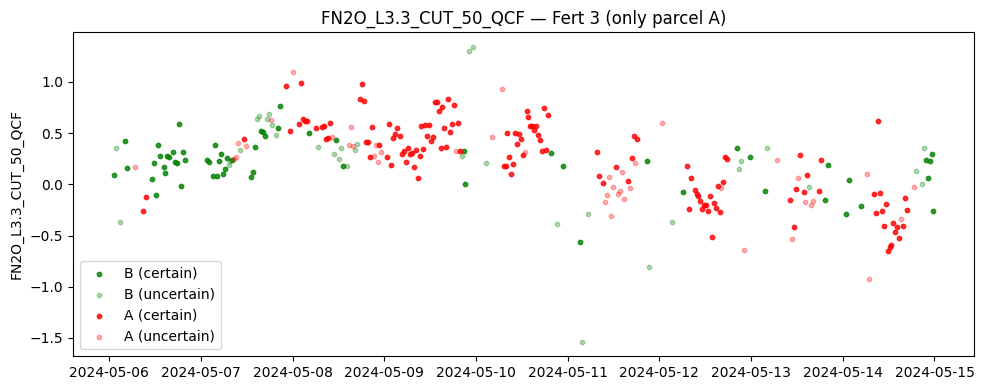

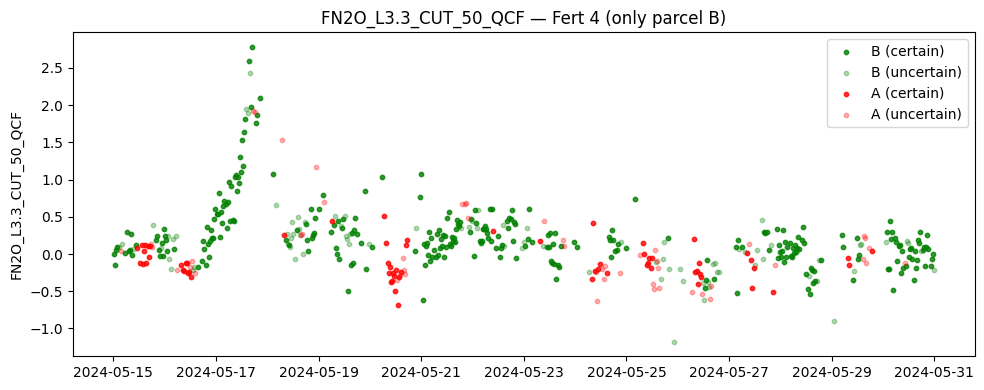

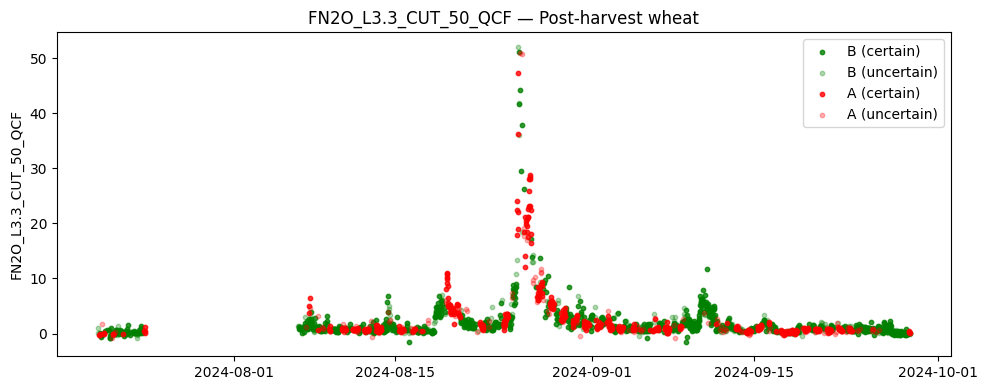

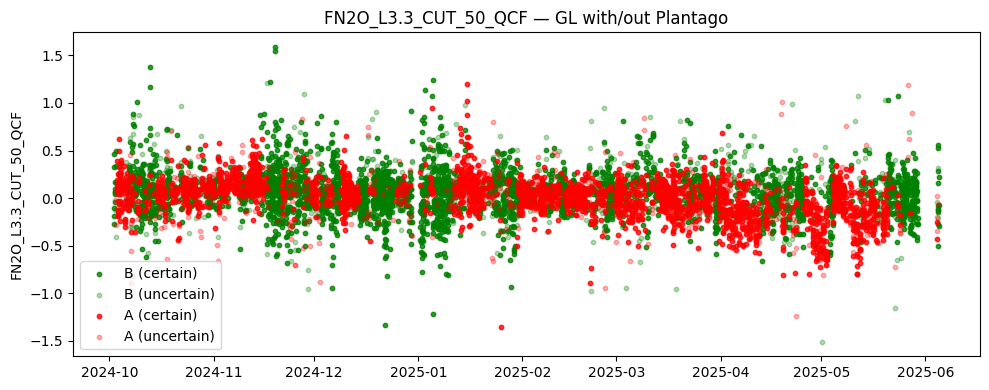

In [9]:
# --- Period definitions ---
periods = [
    ("Fert 1",  "2024-03-05", "2024-03-30"),
    ("Fert 2",  "2024-04-09", "2024-05-05"),
    ("Fert 3 (only parcel A)", "2024-05-06", "2024-05-14"),
    ("Fert 4 (only parcel B)", "2024-05-15", "2024-05-30"),
    ("Post-harvest wheat", "2024-07-20", "2024-10-01"),
    ("GL with/out Plantago", '2024-10-01', '2025-06-05')
]

flux = FLUXES[0]
fixed_colors = {'A': 'red', 'B': 'green', 'buffer': 'gray'}

for label, start, end in periods:
    indat = maindf.loc[start:end].copy()
    if indat.empty:
        print(f"No data for period: {label} ({start} to {end})")
        continue

    plt.figure(figsize=(10, 4))
    for parcel in indat['parcel'].dropna().unique():
        for cert, alpha in [('certain', 0.8), ('uncertain', 0.3)]:
            sub = indat[(indat['parcel'] == parcel) &
                        (indat['parcel_certainty'] == cert)]
            if sub.empty or (flux not in sub.columns):
                continue
            plt.scatter(
                sub.index, sub[flux],
                label=f"{parcel} ({cert})",
                s=10,
                alpha=alpha,
                color=fixed_colors.get(parcel, 'black'),
            )

    plt.title(f"{flux} — {label}")
    plt.xlabel('')
    plt.ylabel(flux)
    plt.legend()
    plt.tight_layout()
    plt.show()

# PRELIMINARY COMPARISON TRT

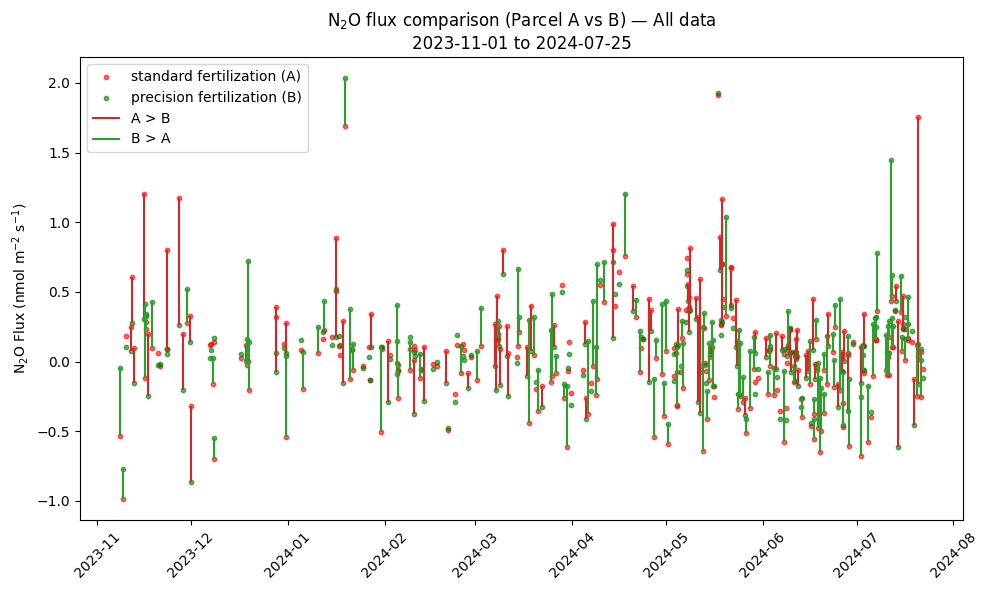

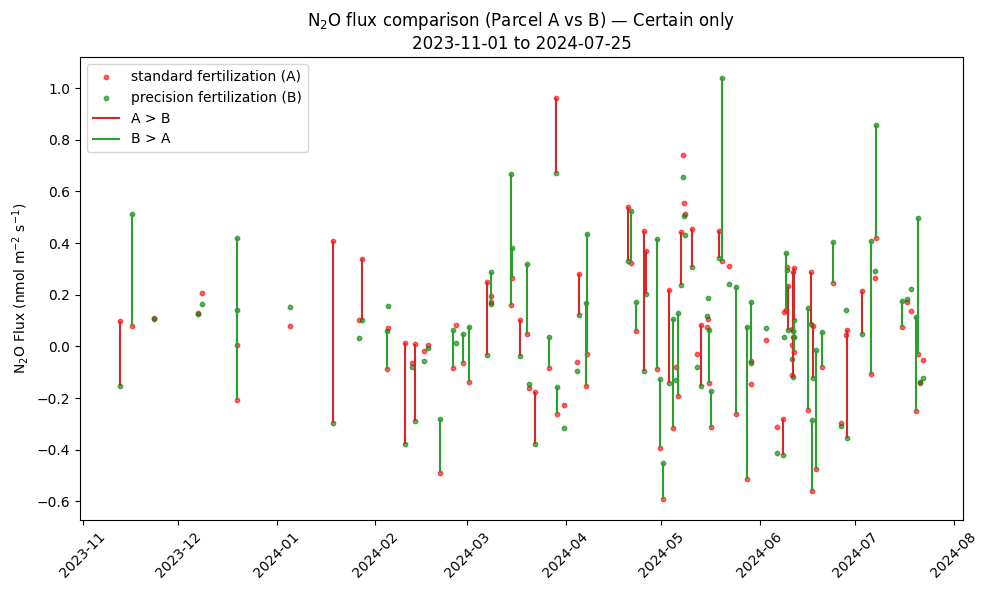

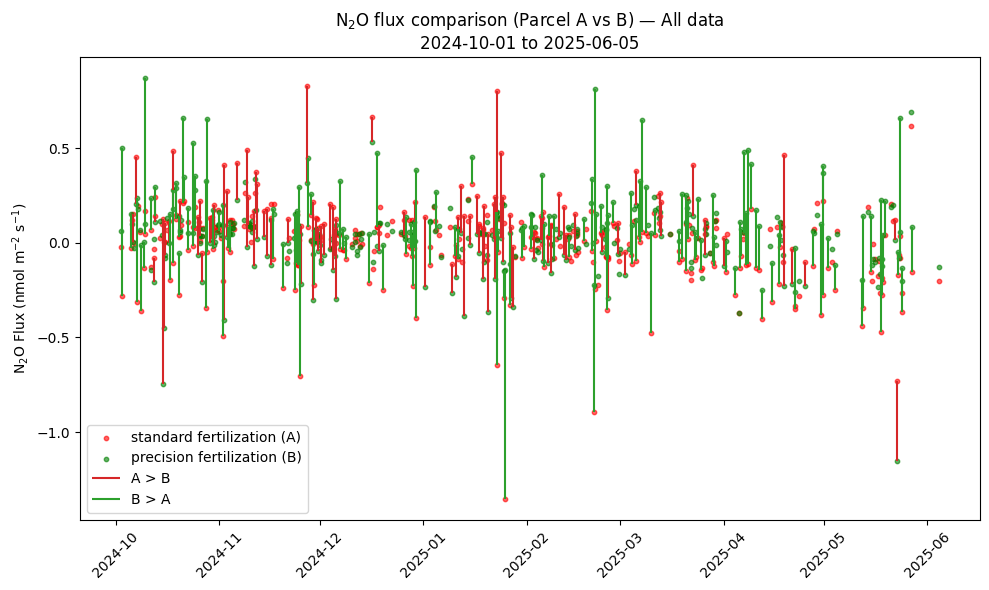

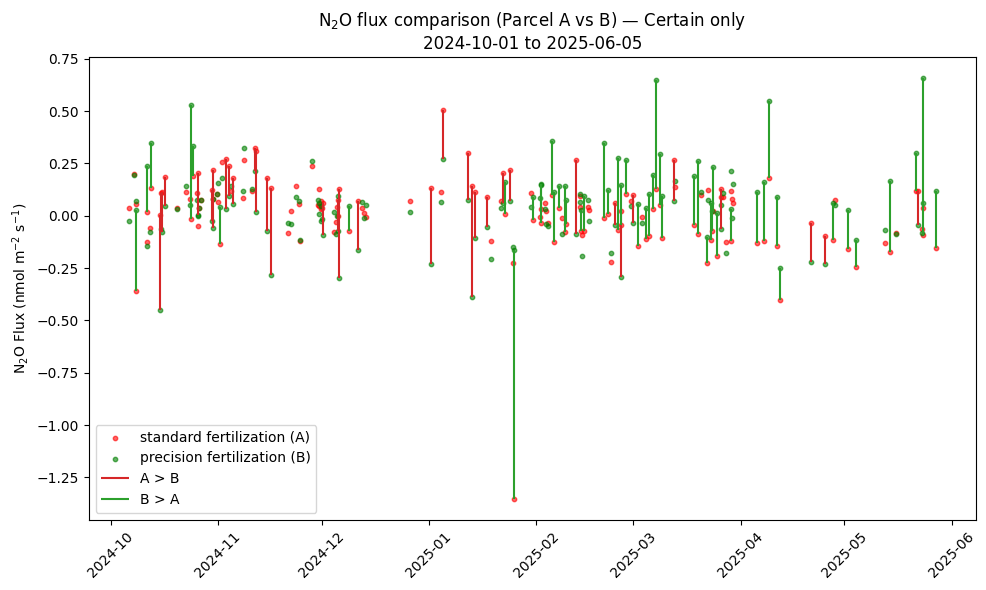

In [ ]:
# Define period of interest
df_n2o = maindf.copy()

# Build parcel-specific series for FN2O flux comparison
df_n2o = df_n2o[['FN2O_L3.3_CUT_50_QCF', 'parcel', 'parcel_certainty']].copy()
df_n2o_certain = df_n2o.copy()
df_n2o['n2o_flux_A'] = np.nan
df_n2o['n2o_flux_B'] = np.nan
mask_A = df_n2o['parcel'] == 'A'
mask_A_certain   = mask_A & (df_n2o_certain['parcel_certainty'] == 'certain')
mask_B = df_n2o['parcel'] == 'B'
mask_B_certain   = mask_B & (df_n2o_certain['parcel_certainty'] == 'certain')
df_n2o.loc[mask_A, 'n2o_flux_A'] = df_n2o.loc[mask_A, 'FN2O_L3.3_CUT_50_QCF']
df_n2o.loc[mask_B, 'n2o_flux_B'] = df_n2o.loc[mask_B, 'FN2O_L3.3_CUT_50_QCF']
df_n2o_certain.loc[mask_A, 'n2o_flux_A'] = df_n2o_certain.loc[mask_A_certain, 'FN2O_L3.3_CUT_50_QCF']
df_n2o_certain.loc[mask_B, 'n2o_flux_B'] = df_n2o_certain.loc[mask_B_certain, 'FN2O_L3.3_CUT_50_QCF']
df_n2o = df_n2o.drop(columns=['parcel', 'parcel_certainty', 'FN2O_L3.3_CUT_50_QCF'])
df_n2o_certain = df_n2o_certain.drop(columns=['parcel', 'parcel_certainty', 'FN2O_L3.3_CUT_50_QCF'])

# Resample (specify the period and the aggregation method)
sampling_period = '4h'
resampled_df = df_n2o.resample(sampling_period).median()
resampled_df_certain = df_n2o_certain.resample(sampling_period).median()

# Difference (A - B)
resampled_df['flux_diff_A-B'] = resampled_df['n2o_flux_A'] - resampled_df['n2o_flux_B']
resampled_df_certain['flux_diff_A-B'] = resampled_df_certain['n2o_flux_A'] - resampled_df_certain['n2o_flux_B']

# Ensure pairs: drop rows where either A or B is NaN
resampled_df = resampled_df.dropna(how='any')
resampled_df_certain = resampled_df_certain.dropna(how='any')

periods = [
    ("2023-11-01", "2024-07-25"),  # Wheat
    ("2024-10-01", "2025-06-05"),  # Grassland
]
for start, end in periods:
    for df, title in [
        (resampled_df, "All data"),
        (resampled_df_certain, "Certain only"),
    ]:
        # Subset by date range
        subdf = df.loc[start:end]

        a = subdf['n2o_flux_A']
        b = subdf['n2o_flux_B']
        x = subdf.index

        eps = 0.1  # detection limit
        pos = a > b + eps   # A > B
        neg = b > a + eps   # B > A

        plt.figure(figsize=(10, 6))
        plt.scatter(x, a, label='standard fertilization (A)', c='red', s=10, alpha=0.6)
        plt.scatter(x, b, label='precision fertilization (B)', c='green', s=10, alpha=0.6)

        # vertical connectors
        plt.vlines(x[pos], ymin=b[pos], ymax=a[pos], colors='tab:red', alpha=1, linewidth=1.5, label='A > B')
        plt.vlines(x[neg], ymin=a[neg], ymax=b[neg], colors='tab:green', alpha=1, linewidth=1.5, label='B > A')

        plt.title(f"N$_2$O flux comparison (Parcel A vs B) — {title}\n{start} to {end}")
        plt.ylabel('N$_{2}$O Flux (nmol m$^{-2}$ s$^{-1}$)')
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

## Cumulative sums (A vs B)

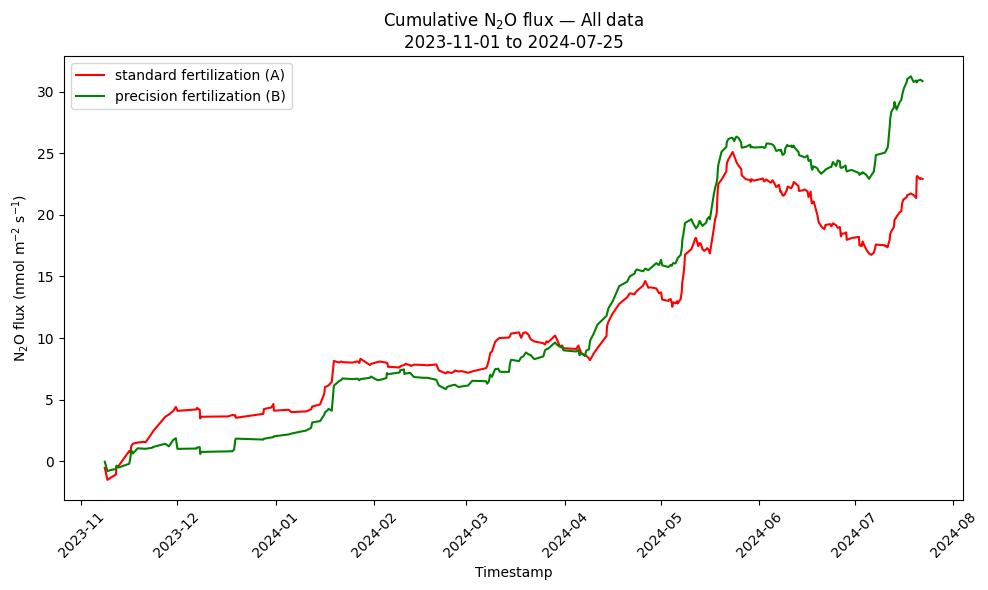

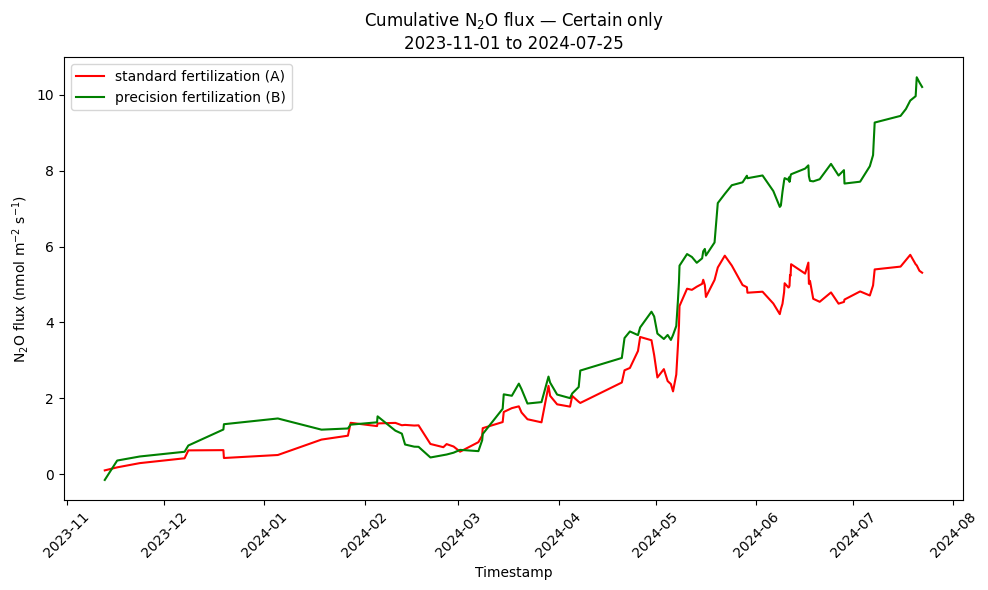

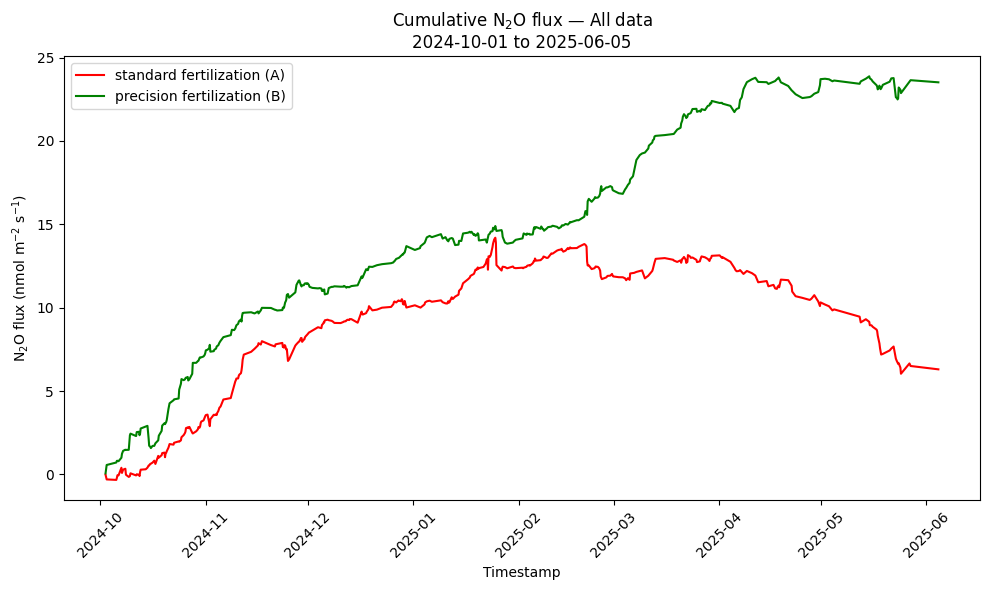

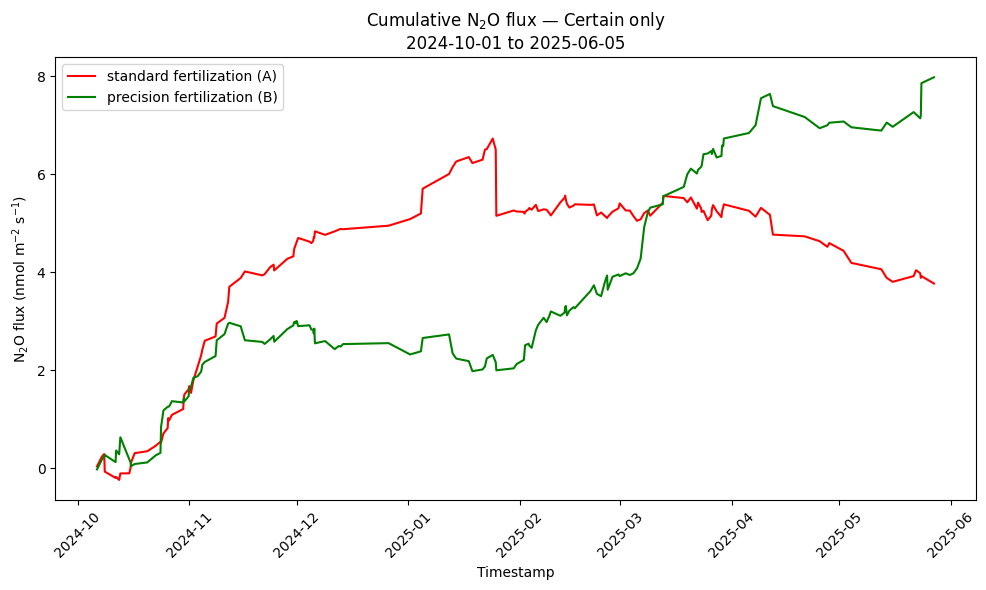

In [30]:
for start, end in periods:
    for df, title in [
        (resampled_df, "All data"),
        (resampled_df_certain, "Certain only"),
    ]:
        # Subset by date range
        subdf = df.loc[start:end]

        # Cumulative sums
        cum_df = pd.DataFrame(index=df.index)
        cum_df['n2o_flux_A'] = subdf['n2o_flux_A'].cumsum()
        cum_df['n2o_flux_B'] = subdf['n2o_flux_B'].cumsum()

        # Plot cumulative sums
        plt.figure(figsize=(10, 6))
        plt.plot(cum_df.index, cum_df['n2o_flux_A'], label='standard fertilization (A)', color='red')
        plt.plot(cum_df.index, cum_df['n2o_flux_B'], label='precision fertilization (B)', color='green')
        plt.title(f"Cumulative N$_2$O flux — {title}\n{start} to {end}")
        plt.xlabel('Timestamp')
        plt.ylabel('N$_{2}$O flux (nmol m$^{-2}$ s$^{-1}$)')
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

## Difference series and statistics

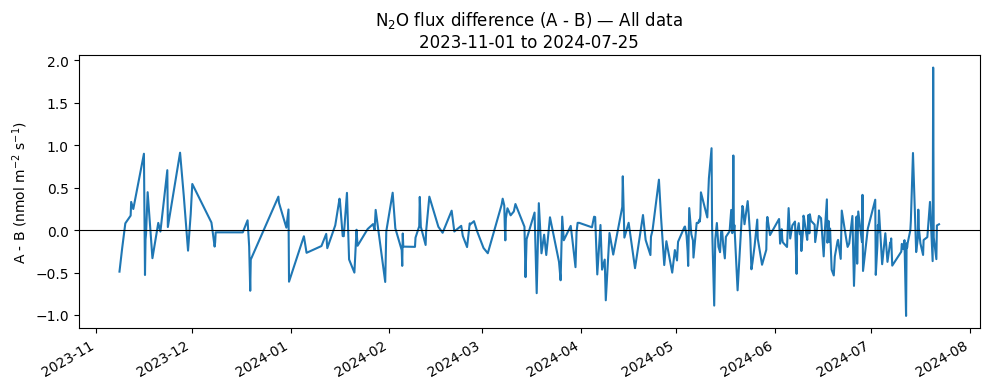

--- All data ---
2023-11-01 to 2024-07-25
Average difference (A - B): -0.027 nmol m^-2 s^-1
T-statistic: -1.460, p-value: 0.145


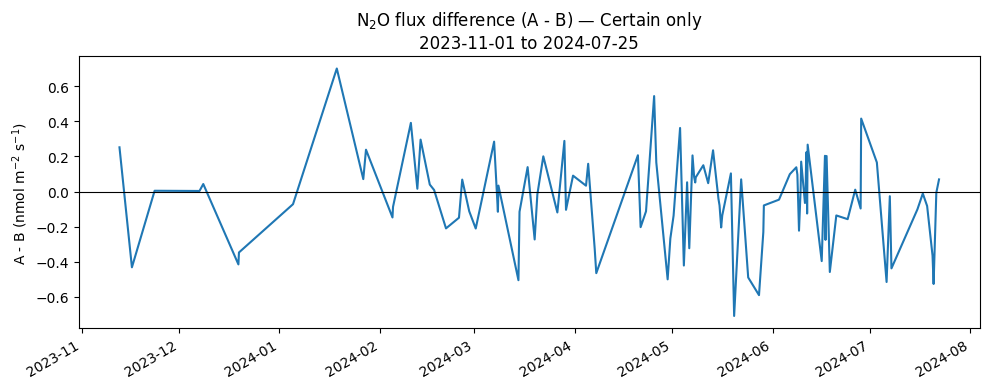

--- Certain only ---
2023-11-01 to 2024-07-25
Average difference (A - B): -0.047 nmol m^-2 s^-1
T-statistic: -1.876, p-value: 0.0635


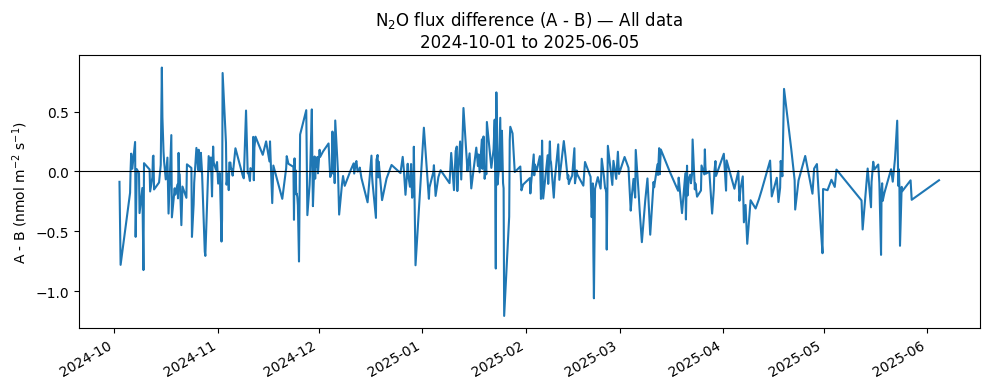

--- All data ---
2024-10-01 to 2025-06-05
Average difference (A - B): -0.042 nmol m^-2 s^-1
T-statistic: -3.470, p-value: 0.000575


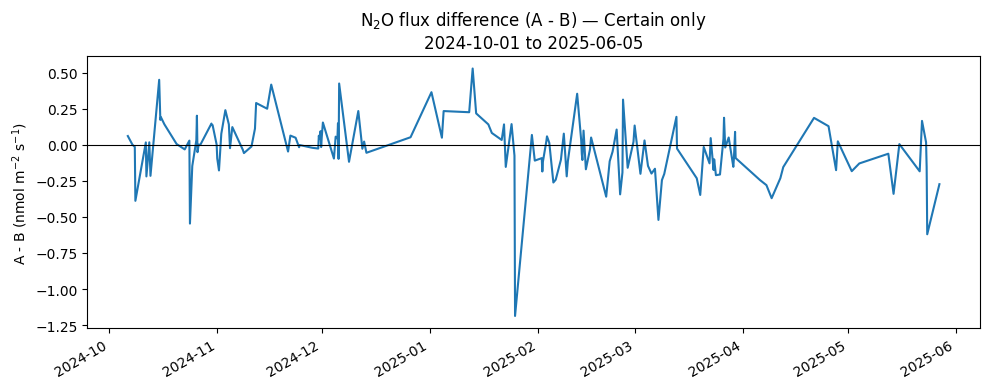

--- Certain only ---
2024-10-01 to 2025-06-05
Average difference (A - B): -0.027 nmol m^-2 s^-1
T-statistic: -1.611, p-value: 0.109


In [32]:
# Relative difference time series
for start, end in periods:
    for df, title in [
        (resampled_df, "All data"),
        (resampled_df_certain, "Certain only"),
    ]:
        subdf = df[start:end] 
        ax = subdf['flux_diff_A-B'].plot(kind='line', figsize=(10, 4), x_compat=True)
        ax.axhline(0, color='black', linewidth=0.8)  # Add zero line
        ax.set_title(f"N$_2$O flux difference (A - B) — {title}\n{start} to {end}")
        ax.set_ylabel('A - B (nmol m$^{-2}$ s$^{-1}$)')
        ax.set_xlabel('')
        plt.show()

        # Average difference
        print(f"--- {title} ---\n{start} to {end}")
        avg_diff = subdf['flux_diff_A-B'].mean()
        print(f"Average difference (A - B): {avg_diff:.3f} nmol m^-2 s^-1")

        # Paired t-test
        t_stat, p_value = stats.ttest_rel(subdf['n2o_flux_A'], subdf['n2o_flux_B'])
        print(f"T-statistic: {t_stat:.3f}, p-value: {p_value:.3g}")

# EXPORT

In [24]:
newcols = [c for c in maindf.columns if c not in data_original.columns]
print("NEW VARIABLES ADDED TO THE DATASET:")
for c in newcols:
    print(f"+ {c}")

NEW VARIABLES ADDED TO THE DATASET:
+ parcel
+ parcel_certainty


In [25]:
filename = "71.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC_PARCELS"
maindf.to_csv(f"{filename}.csv", index=True)
save_parquet(data=maindf, filename=filename)

Saved file 71.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC_PARCELS.parquet (5.560 seconds).


'71.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC_PARCELS.parquet'

# End of notebook

In [26]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-09-26 11:35:41
